In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2025-06-23 06:40:01.249939: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-23 06:40:01.271379: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750660801.296660    1653 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750660801.304402    1653 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1750660801.324764    1653 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
# Preprocess function
def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

In [27]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "data/image/training",
    validation_split=0.2,        # 20% validation
    subset="training",
    seed=123,
    image_size=(128, 128),
    batch_size=64,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "data/image/training",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128, 128),
    batch_size=64,
    label_mode="categorical"
)


Found 50240 files belonging to 5 classes.
Using 40192 files for training.
Found 50240 files belonging to 5 classes.
Using 10048 files for validation.


In [28]:
class_names = train_ds.class_names
class_names

['awaphadigom', 'mayangton', 'peeruk', 'phakpai', 'tuningkhok']

In [4]:

# Apply
train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

# Prefetch
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

In [5]:

# --- CNN Model using Functional API ---
input_shape = (128, 128, 3)  # Change if needed
inputs = Input(shape=input_shape)

x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(5, activation='softmax')(x)

model = models.Model(inputs=inputs, outputs=outputs)

# --- Compile the model ---
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# --- Print model summary ---
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 256)  │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 256)  │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,605,893 (17.57 MB)

 Trainable params: 4,604,997 (17.57 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
callback

In [6]:
history=model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25
)


Epoch 1/25


I0000 00:00:1750660979.235707    2023 service.cc:152] XLA service 0x722cf8024710 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1750660979.235784    2023 service.cc:160]   StreamExecutor device (0): Quadro RTX 4000, Compute Capability 7.5
2025-06-23 06:42:59.401704: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1750660980.428395    2023 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-06-23 06:43:02.741696: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=0} for conv %cudnn-conv-bias-activation.9 = (f32[64,256,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,3,128,128]{3,2,1,0} %bitcast.8774, f32[256,3,3,3]{3,2,1,0} %bitcast.8781, f32[256]{0} %bitcast.9775), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cu

628/628 ━━━━━━━━━━━━━━━━━━━━ 0s 655ms/step - accuracy: 0.3789 - loss: 2.0982

2025-06-23 06:50:06.982268: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=0} for conv %cudnn-conv-bias-activation.9 = (f32[64,256,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,3,128,128]{3,2,1,0} %bitcast.685, f32[256,3,3,3]{3,2,1,0} %bitcast.692, f32[256]{0} %bitcast.694), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="functional_1/conv2d_1/convolution" source_file="/home/doa/tf_project/venv/lib/python3.12/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kRelu","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2025-06-23 06:50:07.074812: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ra

628/628 ━━━━━━━━━━━━━━━━━━━━ 536s 824ms/step - accuracy: 0.3790 - loss: 2.0972 - val_accuracy: 0.5488 - val_loss: 1.1022
Epoch 2/25
628/628 ━━━━━━━━━━━━━━━━━━━━ 529s 842ms/step - accuracy: 0.6046 - loss: 0.9823 - val_accuracy: 0.5631 - val_loss: 1.2917
Epoch 3/25
628/628 ━━━━━━━━━━━━━━━━━━━━ 528s 840ms/step - accuracy: 0.7259 - loss: 0.6987 - val_accuracy: 0.8159 - val_loss: 0.4899
Epoch 4/25
628/628 ━━━━━━━━━━━━━━━━━━━━ 527s 839ms/step - accuracy: 0.7999 - loss: 0.5105 - val_accuracy: 0.7661 - val_loss: 0.6059
Epoch 5/25
628/628 ━━━━━━━━━━━━━━━━━━━━ 527s 838ms/step - accuracy: 0.8626 - loss: 0.3762 - val_accuracy: 0.8468 - val_loss: 0.4675
Epoch 6/25
628/628 ━━━━━━━━━━━━━━━━━━━━ 548s 873ms/step - accuracy: 0.9109 - loss: 0.2738 - val_accuracy: 0.8906 - val_loss: 0.3317
Epoch 7/25
628/628 ━━━━━━━━━━━━━━━━━━━━ 506s 805ms/step - accuracy: 0.9360 - loss: 0.1979 - val_accuracy: 0.9212 - val_loss: 0.2610
Epoch 8/25
628/628 ━━━━━━━━━━━━━━━━━━━━ 521s 828ms/step - accuracy: 0.9486 - loss: 0.16

In [7]:
model.save('model.keras')
model.save('model.h5')

In [8]:
history.history

{'accuracy': [0.4482235312461853,
  0.6342804431915283,
  0.7495272755622864,
  0.8143660426139832,
  0.8718152642250061,
  0.9199841022491455,
  0.9416550397872925,
  0.9548417329788208,
  0.967306911945343,
  0.9678045511245728,
  0.9733529090881348,
  0.9782295227050781,
  0.9810410141944885,
  0.9791749715805054,
  0.9822601675987244,
  0.9860668778419495,
  0.9874352812767029,
  0.9857683181762695,
  0.9859424829483032,
  0.9898487329483032,
  0.9884305596351624,
  0.9888535141944885,
  0.9887291193008423,
  0.9888535141944885,
  0.9898487329483032],
 'loss': [1.4908232688903809,
  0.9050236344337463,
  0.6441770195960999,
  0.47451189160346985,
  0.3544704020023346,
  0.24621328711509705,
  0.1838243156671524,
  0.14764009416103363,
  0.11302144080400467,
  0.10841990262269974,
  0.0941811203956604,
  0.07718124240636826,
  0.0665874108672142,
  0.07487382739782333,
  0.06783207505941391,
  0.05136755481362343,
  0.04544539749622345,
  0.053340643644332886,
  0.05438752844929695,

In [9]:
import pickle

In [14]:
with open('history.pkl','wb') as file:
    pickle.dump(history.history,file)

In [17]:
with open('history.pkl','rb') as file:
    f=pickle.load(file)

In [19]:
import matplotlib.pyplot as plt

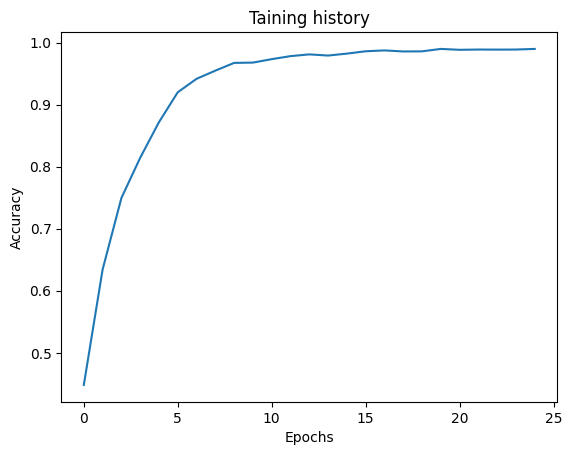

In [23]:
plt.plot(f['accuracy'])
plt.title("Taining history")
plt.xlabel('Epochs')
plt.ylabel("Accuracy")
plt.savefig('accVsEpoch.png')
plt.show()

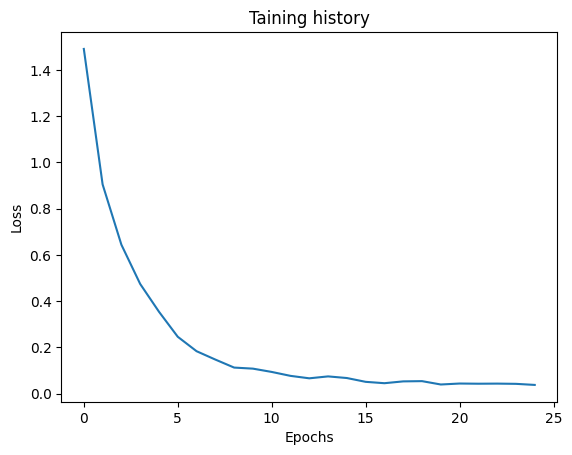

In [24]:
plt.plot(f['loss'])
plt.title("Taining history")
plt.xlabel('Epochs')
plt.ylabel("Loss")
plt.savefig('lossVsEpoch.png')